In [1]:
!pip install cartopy
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import LinearSegmentedColormap


  Using cached cartopy-0.25.0-cp311-cp311-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (6.1 kB)
  Using cached pyshp-3.1.6-py3-none-any.whl.metadata (79 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 55.1 MB/s eta 0:00:00
Using cached pyshp-3.1.6-py3-none-any.whl (73 kB)

[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [2]:


def predicted_kp_ovalest_streamlit(forecast_kp=2, solar_lon=0.0, mag_pole_lat=80.7, mag_pole_lon=-72.7, mode="dark_contrast", target_lat=None, target_lon=None, location_name=None):
    
    base_equatorward_edge = 70.5 - (2.3 * forecast_kp) #67.5
    base_peak_lat = base_equatorward_edge + 3.5
    
    # Create a grid of geographic latitudes and longitudes
    lons = np.linspace(-180, 180, 360)
    lats = np.linspace(30, 90, 180) 
    lon2d, lat2d = np.meshgrid(lons, lats)
    
    # Convert Geographic to Magnetic Latitude
    phi = np.radians(lat2d)
    lam = np.radians(lon2d)
    phi0 = np.radians(mag_pole_lat)
    lam0 = np.radians(mag_pole_lon)
    
    sin_mlat = np.sin(phi) * np.sin(phi0) + np.cos(phi) * np.cos(phi0) * np.cos(lam - lam0)
    sin_mlat = np.clip(sin_mlat, -1.0, 1.0)
    mlat = np.degrees(np.arcsin(sin_mlat))
    
    # Oval "Squish" Mathematics
    day_night_lat_shift = 4.0 * np.cos(np.radians(lon2d - solar_lon)) #was 5.0 befroe
    dynamic_peak_lat = base_peak_lat + day_night_lat_shift
    
    
    # thickness Scaling width grows proportionally with higher Kp values

    #kp_thickness_factor = 1.0 + (0.15 * forecast_kp)  # Kp=0 -> 1.0x, Kp=5 -> 1.75x, Kp=9 -> 2.35x
    #base_std_dev = 3.5 - 1.5 * np.cos(np.radians(lon2d - solar_lon))
    #dynamic_std_dev = base_std_dev * kp_thickness_factor
    #make a bit tighter
    base_std_dev = 1.8 - 0.5 * np.cos(np.radians(lon2d - solar_lon))
    kp_thickness_factor = 1.0 + (0.12 * forecast_kp)
    dynamic_std_dev = base_std_dev * kp_thickness_factor
    
    probability_grid = np.exp(-0.5 * ((mlat - dynamic_peak_lat) / dynamic_std_dev)**2)
    
    cos_diff = np.cos(np.radians(lon2d - solar_lon))

    # Dynamic Peak Center (Teardrop shape: +5° dayside, -5° nightside)
    base_peak_lat = 70.0 - (1.2 * forecast_kp) #68.0 larger is smaller diam
    dynamic_peak_lat = base_peak_lat + (5.0 * cos_diff)

    # Thickness scaling factor (thin dayside arc, broader nightside)
    thickness_scale = 1.0 - 0.40 * cos_diff

    # Slim, controlled widths for inner/outer fades
    equatorward_std = (1.2 + 0.30 * forecast_kp) * thickness_scale
    poleward_std = (1.5 + 0.35 * forecast_kp) * thickness_scale
    plateau_width = (1.5 * forecast_kp) * thickness_scale #originally 0.5, change to 1 or 1.5 to make inner oval closer to pole as kp inc

    # Distance from peak (+ is Poleward/Inside, - is Equatorward/Outside)
    delta_lat = mlat - dynamic_peak_lat

    # 1. Equatorward (Outer Edge): Slim gradient fading south into transparency
    outer_prob = np.exp(-0.5 * (delta_lat / equatorward_std) ** 2)

    # 2. Poleward (Inner Edge): Solid core plateau that transitions into a slim fade north
    shifted_inner_delta = np.maximum(0.0, delta_lat - plateau_width)
    inner_prob = np.exp(-0.5 * (shifted_inner_delta / poleward_std) ** 2)

    # Combine: Outer edge fades south, Inner edge holds solid peak before fading north
    probability_grid = np.where(delta_lat <= 0, outer_prob, inner_prob)
#new code to get probability from oval
    location_prob_pct = None
    if target_lat is not None and target_lon is not None:
        t_phi = np.radians(target_lat)
        t_lam = np.radians(target_lon)
        t_sin_mlat = np.sin(t_phi) * np.sin(phi0) + np.cos(t_phi) * np.cos(phi0) * np.cos(t_lam - lam0)
        t_mlat = np.degrees(np.arcsin(np.clip(t_sin_mlat, -1.0, 1.0)))

        t_cos = np.cos(np.radians(target_lon - solar_lon))
        t_peak_lat = (70.0 - (1.2 * forecast_kp)) + (5.0 * t_cos)
        t_delta = t_mlat - t_peak_lat
        t_scale = 1.0 - 0.40 * t_cos

        if t_delta <= 0:
            t_eq_std = (1.2 + 0.30 * forecast_kp) * t_scale
            point_prob = np.exp(-0.5 * (t_delta / t_eq_std) ** 2)
        else:
            # updated 1.5 multiplier here too
            t_plat = (1.5 * forecast_kp) * t_scale
            t_pol_std = (1.5 + 0.35 * forecast_kp) * t_scale
            t_shift = max(0.0, t_delta - t_plat)
            point_prob = np.exp(-0.5 * (t_shift / t_pol_std) ** 2)

        raw_pct = point_prob * 100.0
        location_prob_pct = raw_pct if raw_pct >= 0.1 else 0.0
    # Map Theme Styling
    if mode == "light":
        fig_bg = "#ffffff"
        ocean_bg = "#e2f1f8"
        land_bg = "#e5e7eb"
        coast_color = "#374151"
        border_color = "#9ca3af"
        grid_color = "#cbd5e1"
        label_color = "#374151"
        text_color = "#111827"
    else:  # 'dark_contrast'
        fig_bg = "#121722"
        ocean_bg = "#1c2638"
        land_bg = "#343e52"
        coast_color = "#9aa5b8"
        border_color = "#525e75"
        grid_color = "#414d63"
        label_color = "#e2e8f0"
        text_color = "#ffffff"

    # Color Map Semi-transparent green gradient
    colors = [
        (0.0, 1.0, 0.3, 0.0),     
        (0.0, 1.0, 0.3, 0.20),    
        (0.0, 1.0, 0.3, 0.50),    
        (0.0, 1.0, 0.3, 0.80)     
    ]
    aurora_cmap = LinearSegmentedColormap.from_list("aurora_green", colors)
    
    fig = plt.figure(figsize=(10, 10))
    fig.patch.set_facecolor(fig_bg) 
    
    ax = plt.axes(projection=ccrs.NorthPolarStereo(central_longitude=-90))
    ax.set_facecolor(ocean_bg)
    
    ax.add_feature(cfeature.OCEAN, facecolor=ocean_bg)
    ax.add_feature(cfeature.LAND, facecolor=land_bg, edgecolor=border_color)
    ax.add_feature(cfeature.COASTLINE, edgecolor=coast_color, linewidth=1.1)
    ax.add_feature(cfeature.BORDERS, linestyle=":", edgecolor=border_color)
    
    ax.set_extent([-180, 180, 30, 90], crs=ccrs.PlateCarree())
    
    contour = ax.contourf(
        lon2d, lat2d, probability_grid, 
        levels=np.linspace(0.1, 1.0, 20),
        cmap=aurora_cmap, 
        transform=ccrs.PlateCarree(), 
        zorder=2
    )
#New code, plotting location on map
    if target_lat is not None and target_lon is not None:
        ax.plot(
            target_lon, target_lat, 
            marker='o', color='#ff3366', markersize=8, 
            transform=ccrs.PlateCarree(), zorder=5
        )
    gl = ax.gridlines(draw_labels=True, dms=True, color=grid_color, linestyle="--")

    #Styling
    gl.xlabel_style = {"color": label_color, "size": 10, "weight": "bold"}
    gl.ylabel_style = {"color": label_color, "size": 10, "weight": "bold"}
    title_text = f"Auroral Oval Forecast (Kp = {forecast_kp})\n{location_name}: {location_prob_pct:.1f}% Probability"

    plt.title(title_text, fontsize=15, pad=15, fontweight="bold", color=text_color)

    # Change plt.show() to return fig for scripts
    plt.show()
    #return fig

In [3]:
LOCATIONS = {
    # --- Prime Aurora Hotspots (High Latitude) ---
    "Tromsø, Norway": (69.65, 18.96),
    "Abisko, Sweden": (68.35, 18.83),
    "Rovaniemi, Finland": (66.50, 25.73),
    "Reykjavík, Iceland": (64.15, -21.94),
    "Kangerlussuaq, Greenland": (67.01, -50.72),
    "Longyearbyen, Svalbard": (78.22, 15.63),
    "Fairbanks, Alaska": (64.84, -147.72),
    "Yellowknife, Canada": (62.45, -114.37),
    "Whitehorse, Canada": (60.72, -135.05),
    "Churchill, Canada": (58.77, -94.17),
    "Murmansk, Russia": (68.97, 33.08),

    # --- Mid-Latitude Benchmarks (Great for testing high Kp storms) ---
    "Anchorage, Alaska": (61.21, -149.90),
    "Helsinki, Finland": (60.17, 24.94),
    "Oslo, Norway": (59.91, 10.75),
    "Stockholm, Sweden": (59.33, 18.07),
    "Edinburgh, Scotland": (55.95, -3.19),
    "Dublin, Ireland": (53.35, -6.26),
    "Berlin, Germany": (52.52, 13.40),
    "London, UK": (51.51, -0.13),
    "Calgary, Canada": (51.05, -114.07),
    "Seattle, USA": (47.61, -122.33),
    "Minneapolis, USA": (44.98, -93.27),
    "Boston, USA": (42.36, -71.06),
    "Chicago, USA": (41.88, -87.63),
    "New York City, USA": (40.71, -74.01),
}

selected_location_name = "Tromsø, Norway"
target_lat, target_lon = LOCATIONS[selected_location_name]


/root/venv/lib/python3.11/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_ocean.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/root/venv/lib/python3.11/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/root/venv/lib/python3.11/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/root/venv/lib/python3.11/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


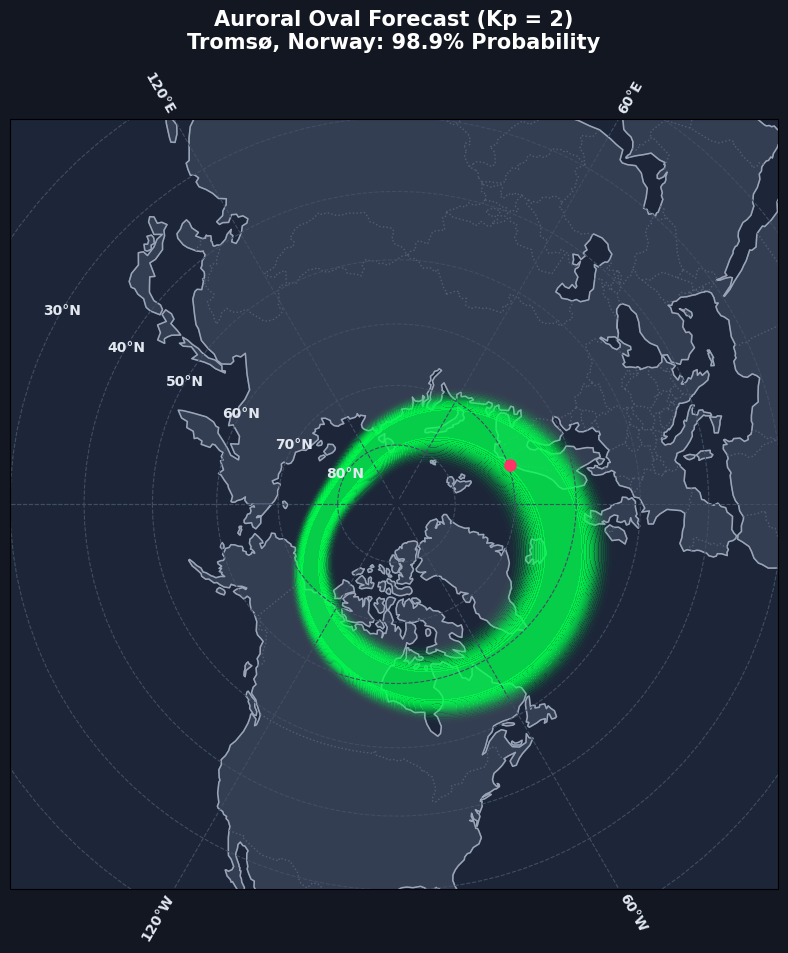

In [4]:
predicted_kp_ovalest_streamlit(forecast_kp=2, solar_lon=180.0, mag_pole_lat=80.7, mag_pole_lon=-72.7, mode="dark_contrast", target_lat=target_lat, target_lon=target_lon, location_name=selected_location_name)

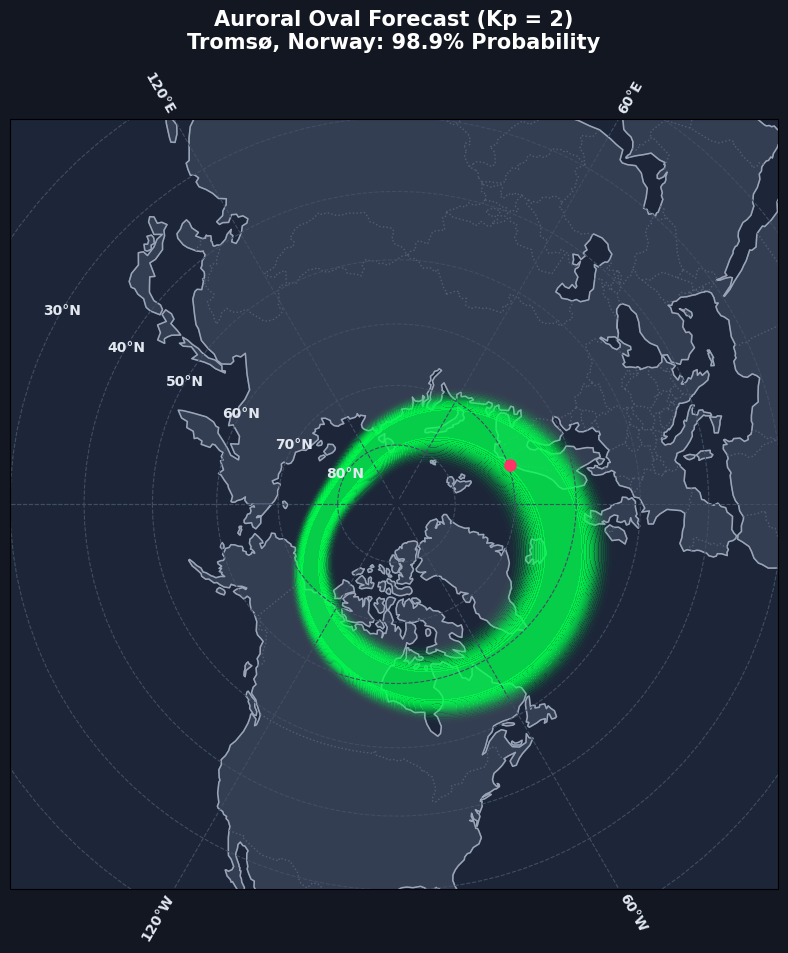

In [5]:
predicted_kp_ovalest_streamlit(forecast_kp=2, solar_lon=180.0, mag_pole_lat=80.7, mag_pole_lon=-72.7, mode="dark_contrast", target_lat=target_lat, target_lon=target_lon, location_name=selected_location_name)

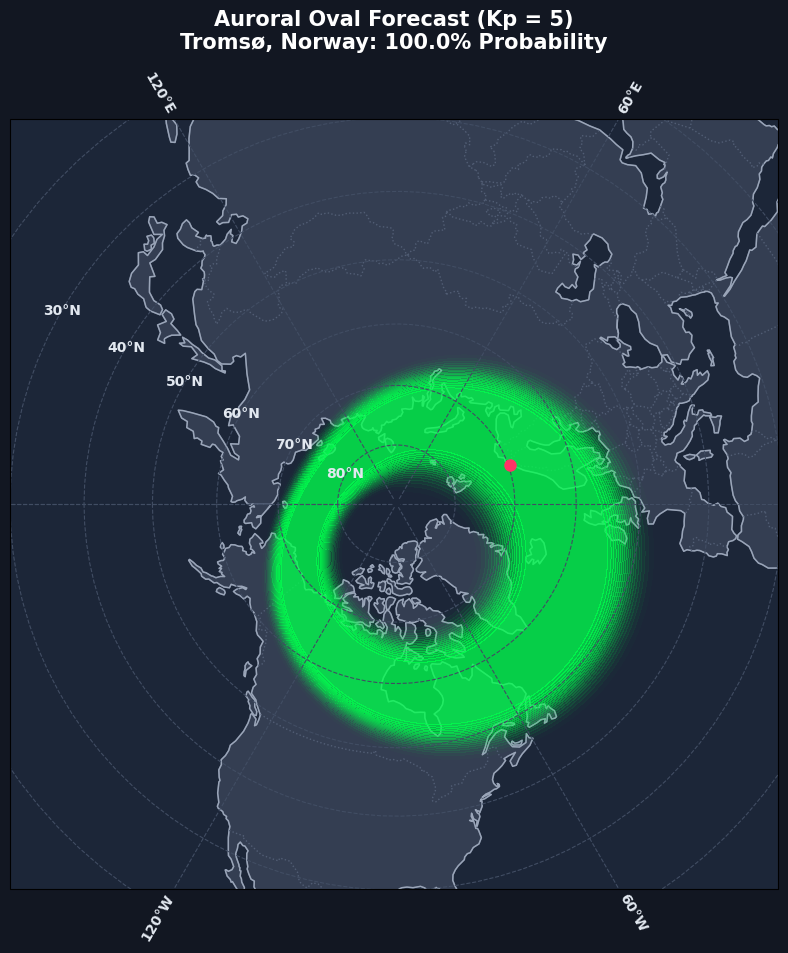

In [6]:
predicted_kp_ovalest_streamlit(forecast_kp=5, solar_lon=180.0, mag_pole_lat=80.7, mag_pole_lon=-72.7, mode="dark_contrast", target_lat=target_lat, target_lon=target_lon, location_name=selected_location_name)

Predicted vs actual visuzlizations

In [7]:
# dummy data
dates = pd.date_range("2026-05-24", "2026-06-08", freq="3h")
n = len(dates)

np.random.seed(42)
x = np.linspace(0, 10, 100)
x

array([ 0.        ,  0.1010101 ,  0.2020202 ,  0.3030303 ,  0.4040404 ,
        0.50505051,  0.60606061,  0.70707071,  0.80808081,  0.90909091,
        1.01010101,  1.11111111,  1.21212121,  1.31313131,  1.41414141,
        1.51515152,  1.61616162,  1.71717172,  1.81818182,  1.91919192,
        2.02020202,  2.12121212,  2.22222222,  2.32323232,  2.42424242,
        2.52525253,  2.62626263,  2.72727273,  2.82828283,  2.92929293,
        3.03030303,  3.13131313,  3.23232323,  3.33333333,  3.43434343,
        3.53535354,  3.63636364,  3.73737374,  3.83838384,  3.93939394,
        4.04040404,  4.14141414,  4.24242424,  4.34343434,  4.44444444,
        4.54545455,  4.64646465,  4.74747475,  4.84848485,  4.94949495,
        5.05050505,  5.15151515,  5.25252525,  5.35353535,  5.45454545,
        5.55555556,  5.65656566,  5.75757576,  5.85858586,  5.95959596,
        6.06060606,  6.16161616,  6.26262626,  6.36363636,  6.46464646,
        6.56565657,  6.66666667,  6.76767677,  6.86868687,  6.96

In [8]:
dates

DatetimeIndex(['2026-05-24 00:00:00', '2026-05-24 03:00:00',
               '2026-05-24 06:00:00', '2026-05-24 09:00:00',
               '2026-05-24 12:00:00', '2026-05-24 15:00:00',
               '2026-05-24 18:00:00', '2026-05-24 21:00:00',
               '2026-05-25 00:00:00', '2026-05-25 03:00:00',
               ...
               '2026-06-06 21:00:00', '2026-06-07 00:00:00',
               '2026-06-07 03:00:00', '2026-06-07 06:00:00',
               '2026-06-07 09:00:00', '2026-06-07 12:00:00',
               '2026-06-07 15:00:00', '2026-06-07 18:00:00',
               '2026-06-07 21:00:00', '2026-06-08 00:00:00'],
              dtype='datetime64[ns]', length=121, freq='3H')

In [9]:

# simulate background Kp values with a storm peak
np.random.seed(42)
observed = 3 + 1.5 * np.sin(np.linspace(0, 10, n)) + np.random.normal(0, 0.4, n)
# Simulate the storm peak by making the kp higher in one slice
observed[30:40] += 3.5  
predicted = observed + np.random.normal(0, 0.3, n)
predicted


array([2.92586942, 3.49038795, 3.0873643 , 4.15637501, 4.05426738,
       3.21625617, 4.18093412, 4.16308295, 3.58872225, 3.77428313,
       3.9454671 , 3.68538369, 4.50106912, 3.28414663, 4.15418066,
       3.96358593, 3.95615595, 4.85197238, 3.76377355, 4.00319862,
       5.47151427, 3.90342343, 4.53100342, 3.91923669, 4.38073991,
       3.98053861, 3.38495611, 4.47397147, 3.93346875, 3.95309042,
       7.26096003, 7.83146975, 7.25018616, 6.73732886, 7.06981324,
       6.90594621, 6.93737533, 5.44608045, 6.12808458, 6.12404729,
       3.24566007, 3.00869873, 2.18136115, 2.52730081, 1.78050991,
       2.10133839, 2.42796432, 2.29957903, 1.77612272, 0.81505435,
       1.60276159, 1.48035254, 1.43805504, 1.89278992, 2.19425961,
       1.88888681, 1.60194084, 1.29797882, 2.45951341, 2.1091066 ,
       1.11279663, 1.2064905 , 1.3543404 , 1.16607677, 2.31921639,
       2.54134814, 1.89103679, 2.18121835, 1.82290288, 1.845579  ,
       2.74922952, 3.14189153, 2.1928247 , 3.38002536, 1.89331

In [10]:
df = pd.read_csv("/work/data/Processed/preds_2025.csv")

print(df.head())
len(df)

              datetime  y_true    y_pred
0  2025-01-01 00:00:00     4.0  4.605702
1  2025-01-01 03:00:00     5.3  4.433926
2  2025-01-01 06:00:00     5.0  6.344898
3  2025-01-01 09:00:00     6.0  6.193872
4  2025-01-01 12:00:00     6.7  8.365404


2832

In [11]:
dates = df["datetime"]
observed = df["y_true"]
predicted = df["y_pred"]

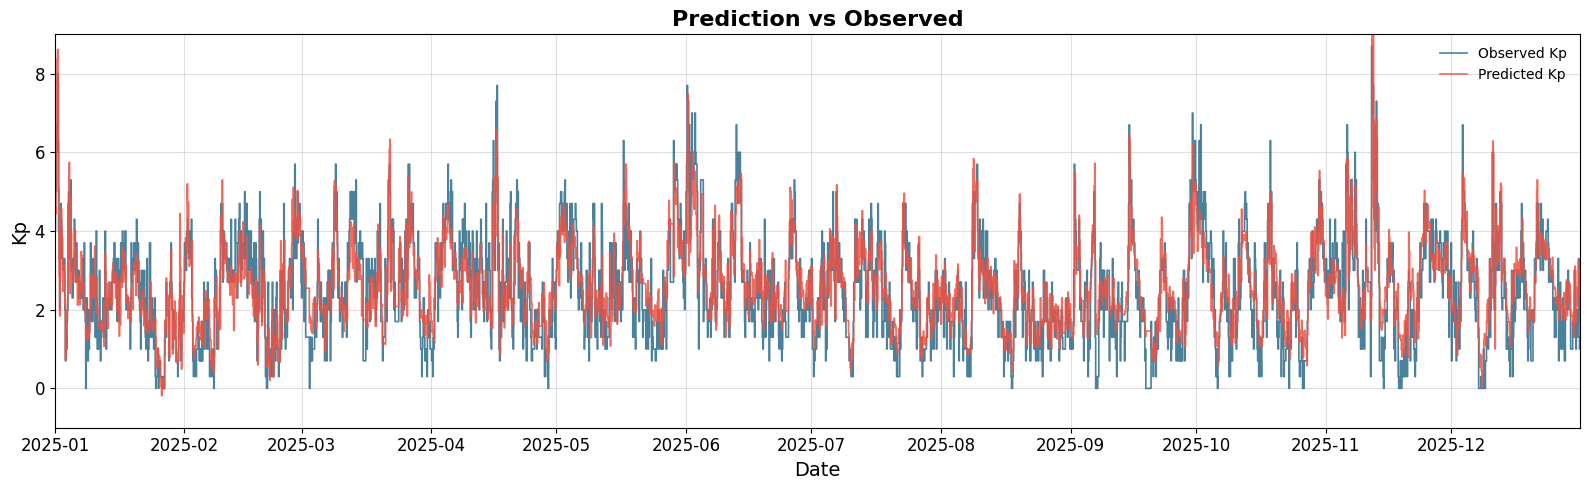

In [29]:

# Ensure datetime is parsed correctly and Series use positional indexing safely
# If df is already loaded from /work/data/Processed/preds_2025.csv, preserve it.
# Otherwise, load it.
try:
    df
except NameError:
    df = pd.read_csv("/work/data/Processed/preds_2025.csv")

# Convert columns to the right types
df["datetime"] = pd.to_datetime(df["datetime"])
df["y_true"] = pd.to_numeric(df["y_true"], errors="coerce")
df["y_pred"] = pd.to_numeric(df["y_pred"], errors="coerce")

# Drop rows with missing plot values and sort by time
df_plot = df.dropna(subset=["datetime", "y_true", "y_pred"]).sort_values("datetime").reset_index(drop=True)

# Use NumPy arrays (or reset-index Series) so dates[-1] cannot be interpreted as label -1
dates = df_plot["datetime"].to_numpy()
observed = df_plot["y_true"].to_numpy()
predicted = df_plot["y_pred"].to_numpy()

# step plot
plt.figure(figsize=(16, 5))
plt.step(dates, observed, where="post", label="Observed Kp", color="#2B6B8A", linewidth=1.2, alpha=0.85,)
plt.step(dates, predicted, where="post", label="Predicted Kp", color="#EE5244", linewidth=1.2, alpha=0.85,)

# titles and formatting
plt.title("Prediction vs Observed", fontsize=16, fontweight="bold")  # Increases title size
plt.ylabel("Kp", fontsize=14)  # Increases y-axis label size
plt.xlabel("Date", fontsize=14)
plt.tick_params(axis="both", labelsize=12)
plt.ylim(-1, 9)
plt.xlim(dates[0], dates[-1])
plt.grid(True, alpha=0.4)
plt.legend(frameon=False)

plt.tight_layout()
plt.show()

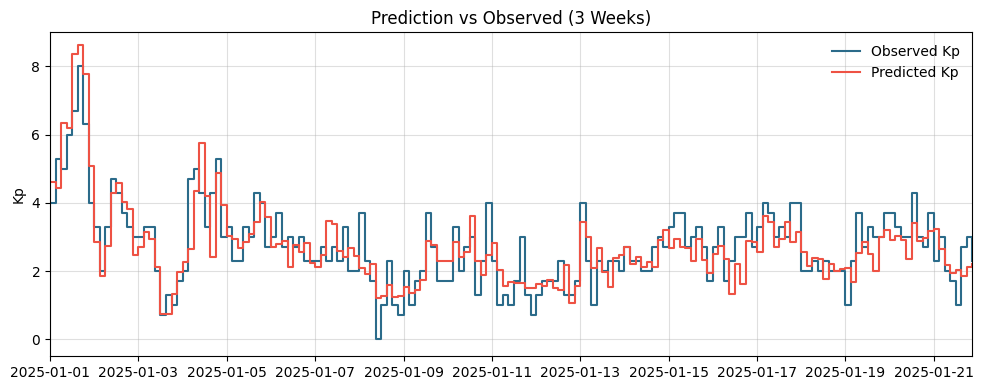

In [13]:

df = pd.read_csv("/work/data/Processed/preds_2025.csv")
df["datetime"] = pd.to_datetime(df["datetime"])

# 3 week
start_date = df["datetime"].min()
end_date = start_date + pd.Timedelta(days=21)
week_df = df[(df["datetime"] >= start_date) & (df["datetime"] < end_date)]

plt.figure(figsize=(10, 4))
plt.step(
    week_df["datetime"],
    week_df["y_true"],
    where="post",
    label="Observed Kp",
    color="#2B6B8A",
)
plt.step(
    week_df["datetime"],
    week_df["y_pred"],
    where="post",
    label="Predicted Kp",
    color="#EE5244",
)

plt.title("Prediction vs Observed (3 Weeks)")
plt.ylabel("Kp")
plt.ylim(-0.5, 9)
plt.xlim(week_df["datetime"].iloc[0], week_df["datetime"].iloc[-1])
plt.grid(True, alpha=0.4)
plt.legend(frameon=False)

plt.tight_layout()
plt.show()

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=4a18bf7d-431c-4909-af8a-a54a62228a78' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>